In [1]:
import numpy as np

In [2]:
!pip install kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ishward","key":"2242b3f25dba3d458aa35a5a136fe1b9"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
lgg-mri-segmentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
!unzip lgg-mri-segmentation.zip -d lgg_dataset

Streaming output truncated to the last 5000 lines.
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7294_19890104/TCGA_DU_7294_19890104_9_mask.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_1.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10_mask.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11_mask.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12_mask.tif  
  inflating: lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCG

In [7]:
base_dir = "/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/"

In [8]:
import os

count_images = 0
count_masks = 0

for root, dirs, files in os.walk(base_dir):
    for f in files:
        if f.endswith(".tif"):
            if "_mask" in f:
                count_masks += 1
            else:
                count_images += 1

print("Images:", count_images)
print("Masks:", count_masks)

Images: 3929
Masks: 3929


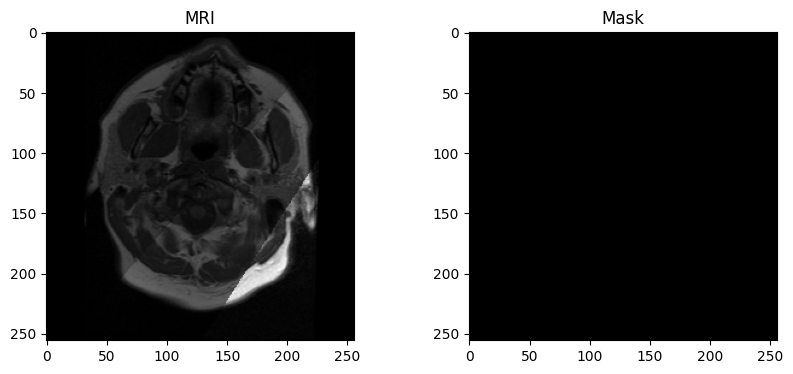

In [9]:
import cv2
import matplotlib.pyplot as plt

sample_img = "/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1.tif"
sample_mask = sample_img.replace(".tif", "_mask.tif")

img = cv2.imread(sample_img, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(sample_mask, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("MRI")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

In [10]:
import os
import cv2
import matplotlib.pyplot as plt

image_path = None
mask_path = None

for root, dirs, files in os.walk(base_dir):
    for f in files:

        if f.endswith(".tif") and "_mask" not in f:

            image_path = os.path.join(root, f)

            mask_name = f.replace(".tif", "_mask.tif")
            mask_path = os.path.join(root, mask_name)

            break

    if image_path is not None:
        break

print(image_path)
print(mask_path)

/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_34.tif
/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_34_mask.tif


Image shape: (256, 256)
Mask shape : (256, 256)


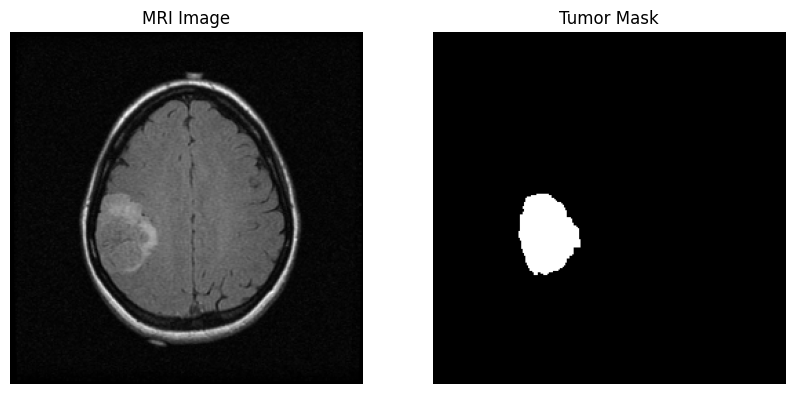

In [11]:
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape :", mask.shape)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

In [12]:
print("Image min :", img.min())
print("Image max :", img.max())

print("Mask min :", mask.min())
print("Mask max :", mask.max())

Image min : 0
Image max : 171
Mask min : 0
Mask max : 255


Let's prove that the mask contains only 2 unique values.

In [13]:
print(np.unique(mask))

[  0 255]


the dataset structure is:

      kaggle_3m/
          patient_1/
              image.tif
              image_mask.tif

          patient_2/
              image.tif
              image_mask.tif



So let's build the file lists.

In [14]:
image_paths = []
mask_paths = []

for root, dirs, files in os.walk(base_dir):

    for f in files:

        if f.endswith(".tif") and "_mask" not in f:

            image_path = os.path.join(root, f)

            mask_path = os.path.join(
                root,
                f.replace(".tif", "_mask.tif")
            )

            if os.path.exists(mask_path):

                image_paths.append(image_path)
                mask_paths.append(mask_path)

print("Images:", len(image_paths))
print("Masks :", len(mask_paths))




Images: 3929
Masks : 3929


In [15]:
print(image_paths[0])
print(mask_paths[0])

print()

print(image_paths[100])
print(mask_paths[100])

/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_34.tif
/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_6404_19850629/TCGA_DU_6404_19850629_34_mask.tif

/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7013_19860523/TCGA_DU_7013_19860523_49.tif
/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7013_19860523/TCGA_DU_7013_19860523_49_mask.tif


Before loading 3929 images, let's load only one pair and inspect it carefully.

In [16]:
sample_img = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
sample_mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

print("Image shape:", sample_img.shape)
print("Mask shape :", sample_mask.shape)

print("Image dtype:", sample_img.dtype)
print("Mask dtype :", sample_mask.dtype)

Image shape: (256, 256)
Mask shape : (256, 256)
Image dtype: uint8
Mask dtype : uint8


actual pixel values stored inside an MRI.

In [17]:
print(sample_img[120:125,120:125])

[[69 74 72 70 72]
 [65 63 66 76 80]
 [63 58 63 72 78]
 [69 67 69 70 70]
 [74 74 72 71 75]]


let's see what normalization does.

In [18]:
normalized_img = sample_img / 255.0

print("Before:")
print(sample_img[120:125,120:125])

print("\nAfter:")
print(normalized_img[120:125,120:125])

Before:
[[69 74 72 70 72]
 [65 63 66 76 80]
 [63 58 63 72 78]
 [69 67 69 70 70]
 [74 74 72 71 75]]

After:
[[0.27058824 0.29019608 0.28235294 0.2745098  0.28235294]
 [0.25490196 0.24705882 0.25882353 0.29803922 0.31372549]
 [0.24705882 0.22745098 0.24705882 0.28235294 0.30588235]
 [0.27058824 0.2627451  0.27058824 0.2745098  0.2745098 ]
 [0.29019608 0.29019608 0.28235294 0.27843137 0.29411765]]


Neural networks generally train faster and more stably when inputs are small.

Then Let's Resize One Image

In [19]:
resized_img = cv2.resize(sample_img, (128,128))
resized_mask = cv2.resize(sample_mask, (128,128))

print("Original:", sample_img.shape)
print("Resized :", resized_img.shape)

Original: (256, 256)
Resized : (128, 128)


Let's Build The Loader

In [20]:
def load_data(image_paths, mask_paths, img_size=(128,128)):

    images = []
    masks = []

    for img_path, mask_path in zip(image_paths, mask_paths):

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, img_size)
        img = img / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, img_size)
        mask = (mask / 255.0 > 0.5).astype(np.float32)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [21]:
images, masks = load_data(image_paths, mask_paths)

print(images.shape)
print(masks.shape)

print(images.min(), images.max())
print(masks.min(), masks.max())

(3929, 128, 128)
(3929, 128, 128)
0.0 0.9215686274509803
0.0 1.0


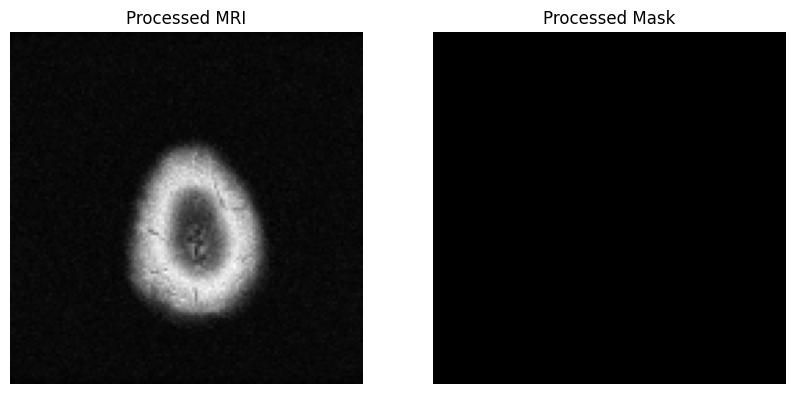

In [22]:
idx = 100

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[idx], cmap='gray')
plt.title("Processed MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[idx], cmap='gray')
plt.title("Processed Mask")
plt.axis("off")

plt.show()

In [23]:
for i in range(len(masks)):

    if np.sum(masks[i]) > 0:
        print("First tumor slice:", i)
        break

First tumor slice: 0


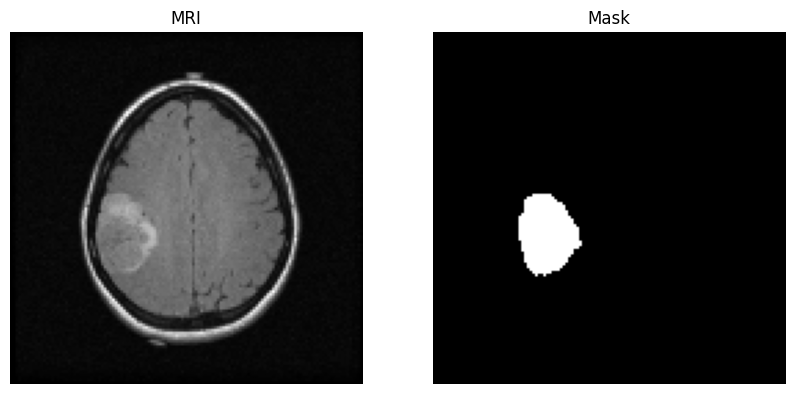

In [24]:
idx = 0

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[idx].squeeze(), cmap='gray')
plt.title("MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[idx].squeeze(), cmap='gray')
plt.title("Mask")
plt.axis("off")

plt.show()

# Adding Channel Dimension

Current shape:

(3929, 128, 128)

But U-Net expects:

(batch, height, width, channels)

Specifically:

(3929, 128, 128, 1)



Because TensorFlow always expects an image to have channels.

Examples:

RGB image:

(128,128,3)

because:Red,Green,Blue - 3

Grayscale image:

(128,128,1)

because:

Only one channel:
Brightness - 1

In [25]:
images = images[..., np.newaxis]
masks = masks[..., np.newaxis]

print(images.shape)
print(masks.shape)

(3929, 128, 128, 1)
(3929, 128, 128, 1)


#Then We Split The Dataset

In [26]:
from sklearn.model_selection import train_test_split

train_images, test_images, train_masks, test_masks = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("Train images shape:", train_images.shape)
print("Train masks shape:", train_masks.shape)
print("Test images shape:", test_images.shape)
print("Test masks shape:", test_masks.shape)


Train images shape: (3143, 128, 128, 1)
Train masks shape: (3143, 128, 128, 1)
Test images shape: (786, 128, 128, 1)
Test masks shape: (786, 128, 128, 1)


In [27]:
print(train_images.dtype)
print(train_masks.dtype)

print(train_images.min(), train_images.max())
print(train_masks.min(), train_masks.max())

float64
float32
0.0 0.9215686274509803
0.0 1.0


#Now We Start U-Net

In [28]:
from tensorflow.keras import layers, models

In [29]:
inputs = layers.Input(shape = (128,128,1))
print(inputs)

<KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>


####1st convolutional layer c1

In [30]:
c1 = layers.Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = 'same')(inputs)
print(c1)

<KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>


In [31]:
c1 = layers.Conv2D(filters = 64,kernel_size = (3,3),activation = 'relu',padding = 'same')(c1)
print(c1)

<KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>


In [32]:
p1 = layers.MaxPooling2D((2,2))(c1)
print(p1)

<KerasTensor shape=(None, 64, 64, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>


####What Did We Gain?

We lost:Fine detail

But gained:Larger receptive field

In [33]:
c2 = layers.Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding = 'same')(p1)
print(c2)

<KerasTensor shape=(None, 64, 64, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>


In [34]:
c2 = layers.Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding = 'same')(c2)

print(c2)

<KerasTensor shape=(None, 64, 64, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_5>


In [35]:
p2 = layers.MaxPooling2D((2,2))(c2)
print(p2)

<KerasTensor shape=(None, 32, 32, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>


In [36]:
c3 = layers.Conv2D(filters = 256, kernel_size=(3,3), activation ='relu',padding = 'same')(p2)
print(c3)

<KerasTensor shape=(None, 32, 32, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_7>


In [37]:
c3 = layers.Conv2D( 256,3, activation= 'relu',padding = 'same')(c3)
print(c3)

<KerasTensor shape=(None, 32, 32, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_8>


In [38]:
u2 = layers.UpSampling2D((2,2))(c3)


In [39]:
u2 = layers.Conv2D(filters = 128, kernel_size = (3,3), activation = 'relu', padding = 'same')(u2)
print(u2)

<KerasTensor shape=(None, 64, 64, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_10>


In [40]:
u2 = layers.Concatenate()([u2,c2])
print(u2)

<KerasTensor shape=(None, 64, 64, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_11>


In [41]:
c4 = layers.Conv2D(filters =128 , kernel_size = (3,3), activation = 'relu', padding = 'same')(u2)
print(c4)

<KerasTensor shape=(None, 64, 64, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>


In [42]:
c4 = layers.Conv2D(filters =128 , kernel_size = (3,3), activation = 'relu', padding = 'same')(c4)
print(c4)

<KerasTensor shape=(None, 64, 64, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_13>


In [43]:
u1 = layers.UpSampling2D((2,2))(c4)
print(u1)

<KerasTensor shape=(None, 128, 128, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_14>


In [44]:
u1 = layers.Conv2D(filters = 64, kernel_size = (3,3), activation = 'relu', padding = 'same')(u1)
print(u1)

<KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_15>


In [45]:
u1 = layers.Concatenate()([u1,c1])
print(u1)

<KerasTensor shape=(None, 128, 128, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_16>


In [46]:
c5 = layers.Conv2D(filters = 64, kernel_size = (3,3) , activation  = 'relu', padding = 'same')(u1)
print(c5)

<KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_17>


In [47]:
c5 = layers.Conv2D(filters = 64, kernel_size = (3,3) , activation  = 'relu', padding = 'same')(c5)
print(c5)

<KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>


In [48]:
outputs=layers.Conv2D(1,(1,1),activation='sigmoid')(c5)
print(outputs)

<KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_19>


In [49]:
from tensorflow.keras import backend as K
K.clear_session()

In [50]:
model = models.Model(inputs,outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     73,792 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_9[0][0], 

 Total params: 2,066,497 (7.88 MB)

 Trainable params: 2,066,497 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

dice_coef = 2*intersection/(pred_mask+ true_mask)

In [51]:
import tensorflow.keras.backend as k
def dice_coef(y_true, y_pred, smooth=1):
  y_true_f = k.flatten(y_true)
  y_pred_f= k.flatten(y_pred)

  intersection = k.sum(y_true_f*y_pred_f)

  return (2* intersection+smooth)/(k.sum(y_true_f)+k.sum(y_pred_f)+smooth)


In [52]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics =['accuracy', dice_coef])

In [53]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,040 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ conv2d_6[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     73,792 │ up_sampling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ conv2d_9[0][0], 

 Total params: 2,066,497 (7.88 MB)

 Trainable params: 2,066,497 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(train_images, train_masks,validation_split = 0.1, batch_size = 16,epochs=20)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 85s 344ms/step - accuracy: 0.9844 - dice_coef: 0.0732 - loss: 0.0639 - val_accuracy: 0.9891 - val_dice_coef: 0.0860 - val_loss: 0.0385
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.9893 - dice_coef: 0.1101 - loss: 0.0382 - val_accuracy: 0.9891 - val_dice_coef: 0.1012 - val_loss: 0.0377
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 31s 176ms/step - accuracy: 0.9893 - dice_coef: 0.1320 - loss: 0.0370 - val_accuracy: 0.9891 - val_dice_coef: 0.1333 - val_loss: 0.0351
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.9897 - dice_coef: 0.1635 - loss: 0.0349 - val_accuracy: 0.9896 - val_dice_coef: 0.1602 - val_loss: 0.0342
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.9901 - dice_coef: 0.1795 - loss: 0.0341 - val_accuracy: 0.9896 - val_dice_coef: 0.1481 - val_loss: 0.0353
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 32s 180ms/step - accuracy: 0.9905 - dice_coef: 0.2160 - loss: 0.0330 - val_accuracy: 

In [55]:
test_loss, test_acc, test_dice = model.evaluate(test_images, test_masks)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Dice: {test_dice:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 489ms/step - accuracy: 0.9963 - dice_coef: 0.7541 - loss: 0.0137
Test Loss: 0.0137
Test Accuracy: 0.9963
Test Dice: 0.7541


In [56]:
predictions = model.predict(test_images)
pred_masks = (predictions > 0.5).astype("uint8")

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step


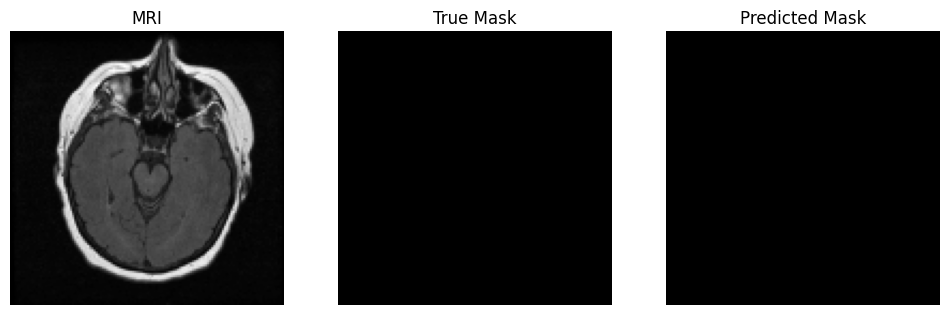

In [57]:
import matplotlib.pyplot as plt

idx = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(test_images[idx].squeeze(), cmap='gray')
plt.title("MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(test_masks[idx].squeeze(), cmap='gray')
plt.title("True Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_masks[idx].squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [58]:
for i in range(len(test_masks)):
    if test_masks[i].sum() > 0:
        print(i)
        break

2


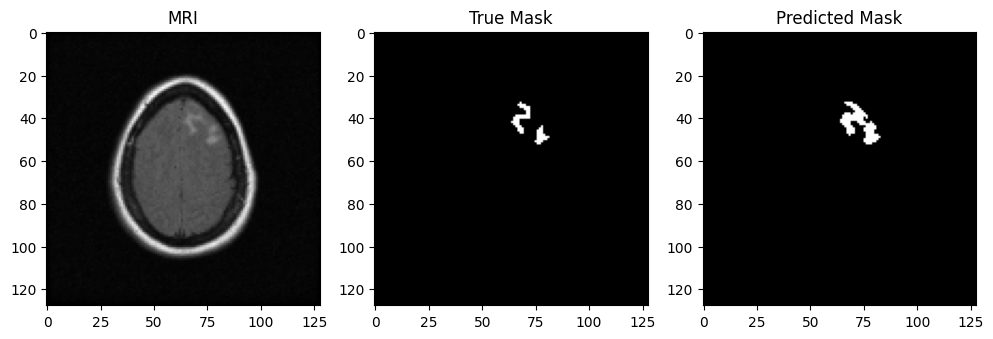

In [59]:
idx = 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(test_images[idx].squeeze(), cmap='gray')
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(test_masks[idx].squeeze(), cmap='gray')
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred_masks[idx].squeeze(), cmap='gray')
plt.title("Predicted Mask")

plt.show()

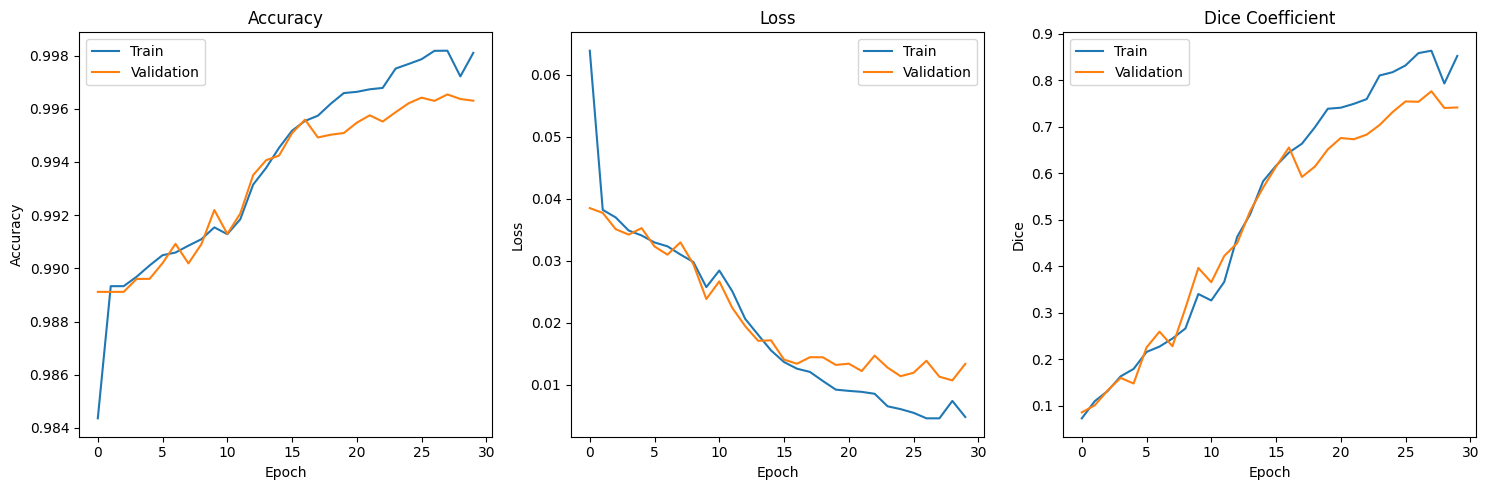

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['dice_coef'],label='Train')
plt.plot(history.history['val_dice_coef'],label='Validation')
plt.title('Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()

plt.tight_layout()
plt.show()

In [61]:
import cv2
import matplotlib.pyplot as plt

def overlay_mask(image, mask, alpha=0.5):

    image = (image * 255).astype('uint8')

    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    overlay = image_rgb.copy()

    overlay[mask > 0] = [255,0,0]

    return cv2.addWeighted(image_rgb,1-alpha,overlay,alpha,0)

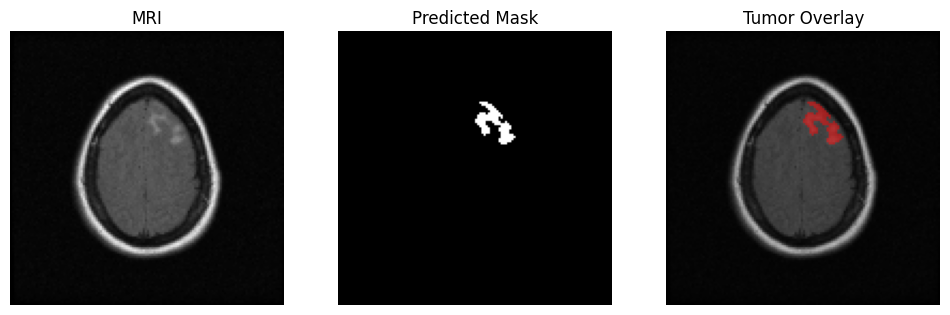

In [62]:
idx = 2

img = test_images[idx].squeeze()
mask = pred_masks[idx].squeeze()

overlay = overlay_mask(img, mask)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title("MRI")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask,cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Tumor Overlay")
plt.axis('off')

plt.show()